In [1]:
# Cargar paquetes
import cv2
import pytesseract
import matplotlib.pyplot as plt
# para usar en windows
# pyteseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

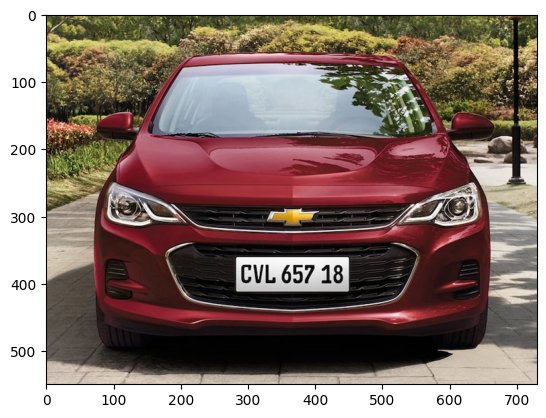

In [2]:
image = cv2.imread('auto.jpg');
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));

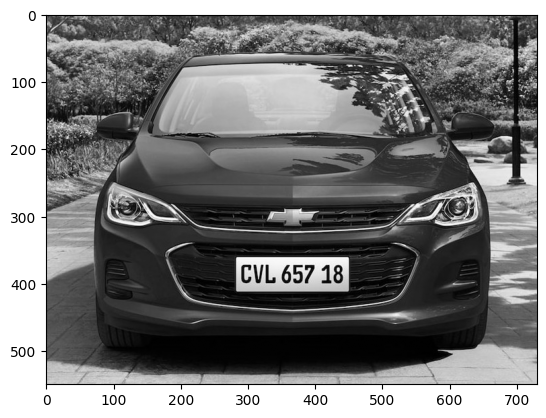

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY);
plt.imshow(gray, cmap='gray');

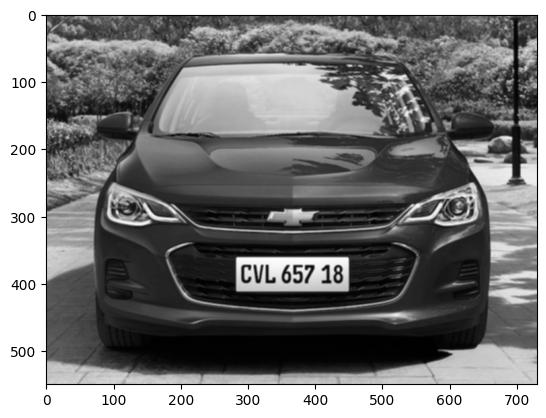

In [4]:
gray = cv2.blur(gray, (3, 3))
plt.imshow(gray, cmap='gray');

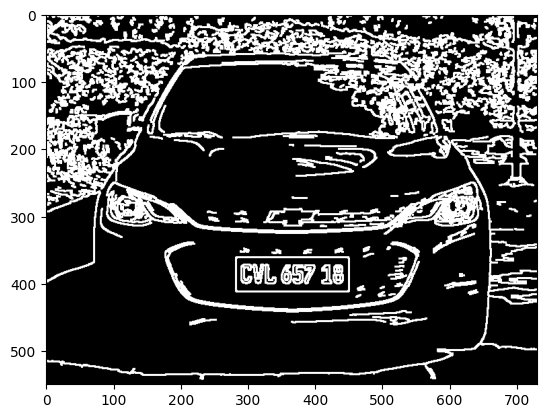

In [5]:
canny = cv2.Canny(gray, 150, 200);
canny = cv2.dilate(canny, None, iterations=1);
plt.imshow(canny, cmap='gray');

In [6]:
# Deteccion de contornos de openCV
contorno, _ = cv2.findContours(canny, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE);

In [7]:
contorno

(array([[[522, 453]],
 
        [[523, 452]],
 
        [[524, 452]],
 
        [[525, 453]],
 
        [[533, 453]],
 
        [[534, 454]],
 
        [[535, 454]],
 
        [[537, 456]],
 
        [[536, 457]],
 
        [[533, 457]],
 
        [[532, 458]],
 
        [[528, 458]],
 
        [[527, 459]],
 
        [[523, 459]],
 
        [[522, 458]],
 
        [[522, 457]],
 
        [[520, 457]],
 
        [[519, 456]],
 
        [[520, 455]],
 
        [[521, 455]],
 
        [[522, 454]]], dtype=int32),
 array([[[448, 453]],
 
        [[447, 454]],
 
        [[425, 454]],
 
        [[424, 455]],
 
        [[401, 455]],
 
        [[400, 456]],
 
        [[370, 456]],
 
        [[369, 457]],
 
        [[368, 457]],
 
        [[367, 456]],
 
        [[364, 456]],
 
        [[364, 458]],
 
        [[365, 458]],
 
        [[366, 459]],
 
        [[371, 459]],
 
        [[372, 458]],
 
        [[402, 458]],
 
        [[403, 457]],
 
        [[426, 457]],
 
        [[427, 456]],
 
   

In [12]:
for c in contorno:
    area = cv2.contourArea(c);
    x, y, w, h = cv2.boundingRect(c);
    epsilon = 0.09*cv2.arcLength(c, True);
    approx = cv2.approxPolyDP(c, epsilon, True);
    if len(approx) == 4 and area > 9000:
        print(f'Area: {area}')
        print(f'x:{x}; y:{y}; w:{w}; h:{h}')
        relAspec = float(w)/h;
        print(f'Relacion de aspecto: {relAspec}') 
        cv2.drawContours(image, [approx], 0, (0, 255, 0), 3);
        if relAspec > 3:
            placa = gray[y:y+h, x:x+w];
            texto = pytesseract.image_to_string(placa, config='--psm 11'.strip())
            print(f'Placa: {texto}')
            cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 3);
            cv2.putText(image, texto, (x-20, y-10), 1, 2.2, (0, 255, 0), 3);

Area: 9007.0
x:281; y:360; w:171; h:54
Relacion de aspecto: 3.1666666666666665
Placa: CVL 657 18



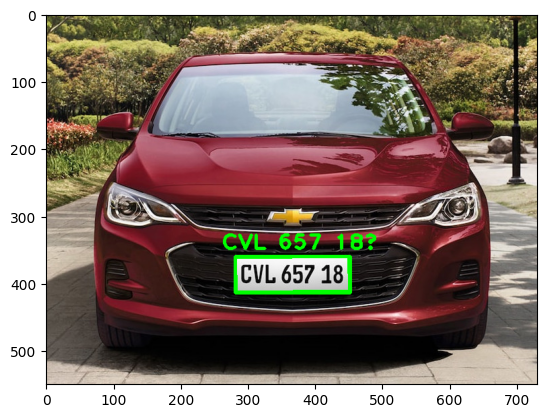

In [13]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));